# Logistic Regression Baseline

Trains a logistic regression baseline on the same feature set used by the Random Forest model (`data/model_ready.parquet`). Uses `modeling_utils` so the feature set, leakage exclusions, train/test split, and metrics format are identical across all models.

**Design choices:**
- **Same features as RF** — leakage-prone columns (`log_enrollment`, `enrollment_actual`, `trial_duration_days`) removed via `remove_leakage_prone_features()`
- **Temporal train/test split** — train on `start_year < 2019`, test on `start_year ≥ 2019`
- **StandardScaler on numeric columns only** — OHE binary dummies left unscaled (rescaling 0/1 dummies distorts their meaning for L2-regularized LR)
- **`class_weight='balanced'`** — compensates for class imbalance (~53% / 37% / 11%)
- **Primary metric: macro F1** — treats all three classes equally

**Label encoding:** 0 = COMPLETED, 1 = TERMINATED, 2 = WITHDRAWN

## Justification for Model


We chose the logistic regression model as our baseline because it is relatively simple and interpretable, and can show us how well linear relationships in the trial features can predict outcome status. Depending on the results, we will see whether a more complex model is needed to understand nonlinear dynamics.

In [1]:
import time

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import polars as pl

from modeling_utils import (
    LABEL_NAMES,
    LEAKAGE_PRONE_COLS,
    load_model_ready,
    remove_leakage_prone_features,
    save_model,
    save_or_update_metrics,
    evaluate_model,
    temporal_split,
)

df, feature_cols = load_model_ready()
# Remove the same leakage-prone columns the RF drops
feature_cols = remove_leakage_prone_features(feature_cols)

print(f"Loaded: {df.shape[0]:,} rows")
print(f"Removed leakage-prone columns: {sorted(LEAKAGE_PRONE_COLS)}")
print(f"Feature count: {len(feature_cols)}")
print(df["label"].value_counts().sort("label"))

Loaded: 53,628 rows
Removed leakage-prone columns: ['enrollment_actual', 'log_enrollment', 'trial_duration_days']
Feature count: 144
shape: (3, 2)
┌───────┬───────┐
│ label ┆ count │
│ ---   ┆ ---   │
│ i8    ┆ u32   │
╞═══════╪═══════╡
│ 0     ┆ 28219 │
│ 1     ┆ 19694 │
│ 2     ┆ 5715  │
└───────┴───────┘


## 1. Feature Columns

Separate continuous numeric features (to be scaled) from binary OHE dummies (left as-is). The numeric list excludes the three leakage-prone columns already removed above.

In [2]:
# Numeric cols to scale — leakage-prone ones already excluded from feature_cols
NUM_COLS = [
    c for c in [
        'num_primary_outcomes', 'num_secondary_outcomes',
        'num_conditions', 'num_drugs', 'num_sites', 'num_collaborators',
        'min_age_years', 'max_age_years', 'age_range_years',
        'approval_year', 'years_since_approval',
    ]
    if c in feature_cols
]

# Binary OHE dummies — everything else that's numeric but not in NUM_COLS
BIN_COLS = [
    c for c in feature_cols
    if c not in NUM_COLS
    and df[c].dtype in (pl.UInt8, pl.Int8, pl.Boolean)
]

print(f"Numeric features  : {len(NUM_COLS)}")
print(f"Binary OHE dummies: {len(BIN_COLS)}")
print(f"Total features    : {len(NUM_COLS) + len(BIN_COLS)}")

Numeric features  : 11
Binary OHE dummies: 133
Total features    : 144


## 2. Temporal Train/Test Split

Trials with `start_year < 2019` → train; `start_year ≥ 2019` → test. This simulates real deployment: predict outcomes for future trials using only past data.

In [3]:
import polars as pl
from modeling_utils import SPLIT_YEAR

train = df.filter(pl.col("start_year") < SPLIT_YEAR)
test  = df.filter(pl.col("start_year") >= SPLIT_YEAR)

print(f"Train: {len(train):,} rows (start_year < {SPLIT_YEAR})")
print(f"Test:  {len(test):,} rows  (start_year ≥ {SPLIT_YEAR})")
print("\nTrain label distribution:")
print(train["label"].value_counts().sort("label"))
print("\nTest label distribution:")
print(test["label"].value_counts().sort("label"))

Train: 40,209 rows (start_year < 2019)
Test:  13,419 rows  (start_year ≥ 2019)

Train label distribution:
shape: (3, 2)
┌───────┬───────┐
│ label ┆ count │
│ ---   ┆ ---   │
│ i8    ┆ u32   │
╞═══════╪═══════╡
│ 0     ┆ 22075 │
│ 1     ┆ 14773 │
│ 2     ┆ 3361  │
└───────┴───────┘

Test label distribution:
shape: (3, 2)
┌───────┬───────┐
│ label ┆ count │
│ ---   ┆ ---   │
│ i8    ┆ u32   │
╞═══════╪═══════╡
│ 0     ┆ 6144  │
│ 1     ┆ 4921  │
│ 2     ┆ 2354  │
└───────┴───────┘


## 3. Build Feature Matrices & Scale

`StandardScaler` is fit on the training numeric columns only, then applied to both train and test. Binary OHE columns are concatenated unscaled — rescaling 0/1 indicators would shrink them to near-zero and inflate their apparent magnitude relative to continuous features.

In [8]:
import numpy as np

X_train_num = train.select(NUM_COLS).to_numpy().astype(np.float64)
X_test_num  = test.select(NUM_COLS).to_numpy().astype(np.float64)

X_train_bin = train.select(BIN_COLS).to_numpy().astype(np.float64)
X_test_bin  = test.select(BIN_COLS).to_numpy().astype(np.float64)

# Fit scaler on train only — no test leakage
scaler = StandardScaler()
X_train_num_scaled = scaler.fit_transform(X_train_num)
X_test_num_scaled  = scaler.transform(X_test_num)

X_train = np.hstack([X_train_num_scaled, X_train_bin])
X_test  = np.hstack([X_test_num_scaled,  X_test_bin])

y_train = train["label"].to_numpy()
y_test  = test["label"].to_numpy()

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"Feature scale check — numeric col 0 ({NUM_COLS[0]}) mean≈{X_train_num_scaled[:,0].mean():.3f}, std≈{X_train_num_scaled[:,0].std():.3f}")

X_train: (40209, 144)
X_test:  (13419, 144)
Feature scale check — numeric col 0 (num_primary_outcomes) mean≈-0.000, std≈1.000


## 4. Train & Evaluate

`solver='saga'` handles large sparse feature matrices efficiently. `max_iter=3000` ensures convergence on the 147-feature scaled matrix. `class_weight='balanced'` upweights the minority WITHDRAWN class.

In [9]:
start = time.perf_counter()
model = LogisticRegression(
    class_weight="balanced",
    solver="saga",
    max_iter=3000,
    random_state=42,
)
model.fit(X_train, y_train)
training_seconds = time.perf_counter() - start
print(f"Training complete in {training_seconds:.1f} seconds.")

metrics = evaluate_model(
    model=model,
    name="Logistic Regression Baseline",
    slug="logistic_regression",
    x_train=X_train,
    x_test=X_test,
    y_test=y_test,
    training_seconds=training_seconds,
)
save_model(model, "logistic_regression")
save_or_update_metrics(metrics)

target_names = [LABEL_NAMES[i] for i in sorted(LABEL_NAMES)]
print(f"Macro F1:    {metrics['macro_f1']:.4f}")
print(f"Accuracy:    {metrics['accuracy']:.4f}")
print(f"Weighted F1: {metrics['weighted_f1']:.4f}")

Training complete in 70.1 seconds.
Macro F1:    0.4901
Accuracy:    0.5070
Weighted F1: 0.5197


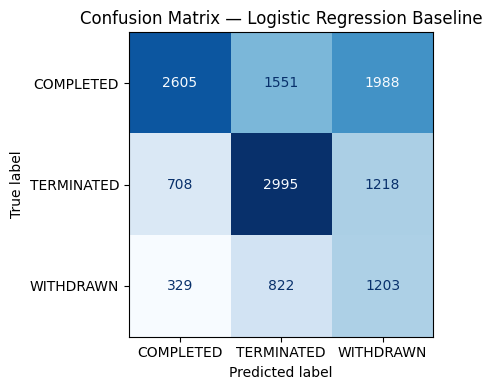

In [10]:
y_pred = model.predict(X_test)
cm = confusion_matrix(y_test, y_pred, labels=[0, 1, 2])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix — Logistic Regression Baseline')
plt.tight_layout()
plt.show()

## 5. Top Predictive Features

Logistic regression coefficients (one row per class, one column per feature). For each class, show the 15 features with the largest absolute coefficient — these are the strongest linear predictors of that outcome.

/var/folders/d5/3zspmjf92d91t10nc68flbhc0000gn/T/ipykernel_46096/1052632891.py:14: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()


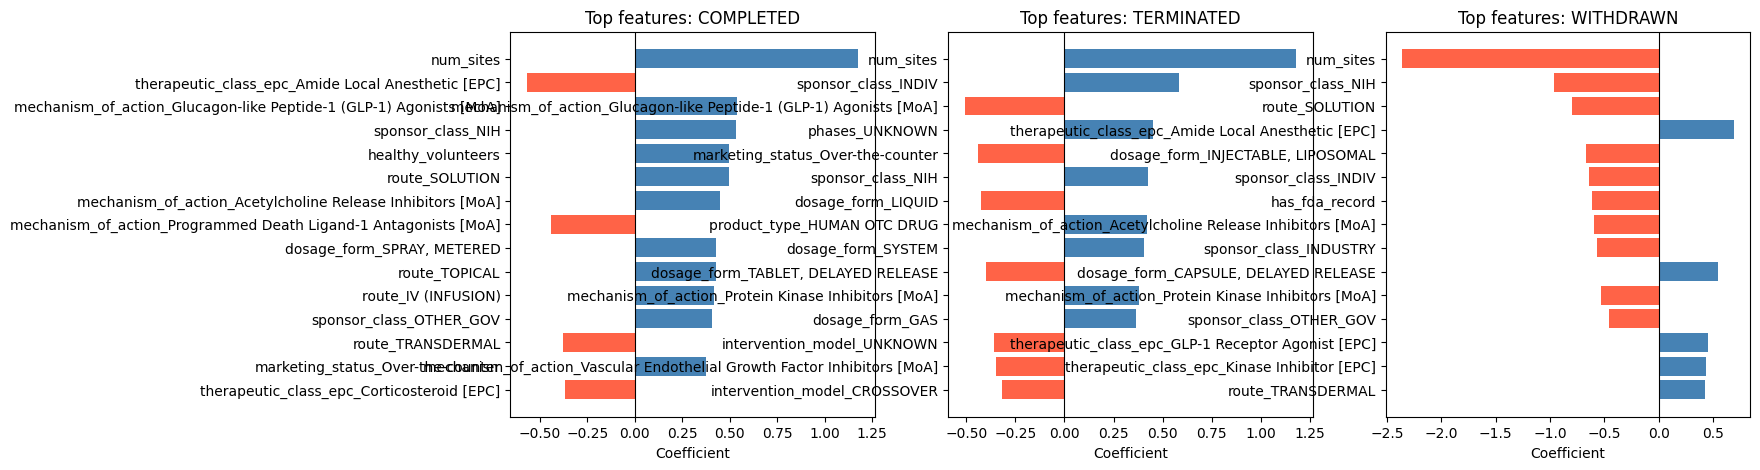

In [11]:
feature_names = NUM_COLS + BIN_COLS

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=False)
for ax, class_idx in zip(axes, [0, 1, 2]):
    coefs = model.coef_[class_idx]
    top_idx = np.argsort(np.abs(coefs))[-15:][::-1]
    top_names = [feature_names[i] for i in top_idx]
    top_vals  = coefs[top_idx]
    colors = ['steelblue' if v > 0 else 'tomato' for v in top_vals]
    ax.barh(top_names[::-1], top_vals[::-1], color=colors[::-1])
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f'Top features: {LABEL_NAMES[class_idx]}')
    ax.set_xlabel('Coefficient')
plt.tight_layout()
plt.show()